------------------------------
#Construction Safety Monitor
------------------------------


In [ ]:
!pip install roboflow ultralytics

#Download Dataset

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="TAwoGmUqqaEf8JaNUoJG")
project = rf.workspace("tharushas-workspace-zmnor").project("ppe-detection-vwfhi")
version = project.version(10)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-Detection-10 in yolov8:: 100%|██████████| 1258/1258 [00:00<00:00, 7103.91it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Train Model

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/PPE-Detection-10/data.yaml",
    epochs=43,
    imgsz=640,


)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PPE-Detection-10/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=43, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e8302d84b00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# loading trained model


In [15]:
local_model_path = "runs/detect/train/weights/best.pt"

# Check if local trained model exists
if os.path.exists(local_model_path):
    print("Loading model from local training...")
    model = YOLO(local_model_path)

else:
    print("Local model not found. Downloading from Drive...")

    # Download trained model
    !wget "https://drive.google.com/uc?id=1Xq5tj-g2SFibMQFqDfE2CnxnSEfmObfM" -O best.pt

    # Load downloaded model
    model = YOLO("best.pt")

print("Model loaded successfully!")

Loading model from local training...
Model loaded successfully!


#Training Results

Loading from local: /content/runs/detect/train/results.png


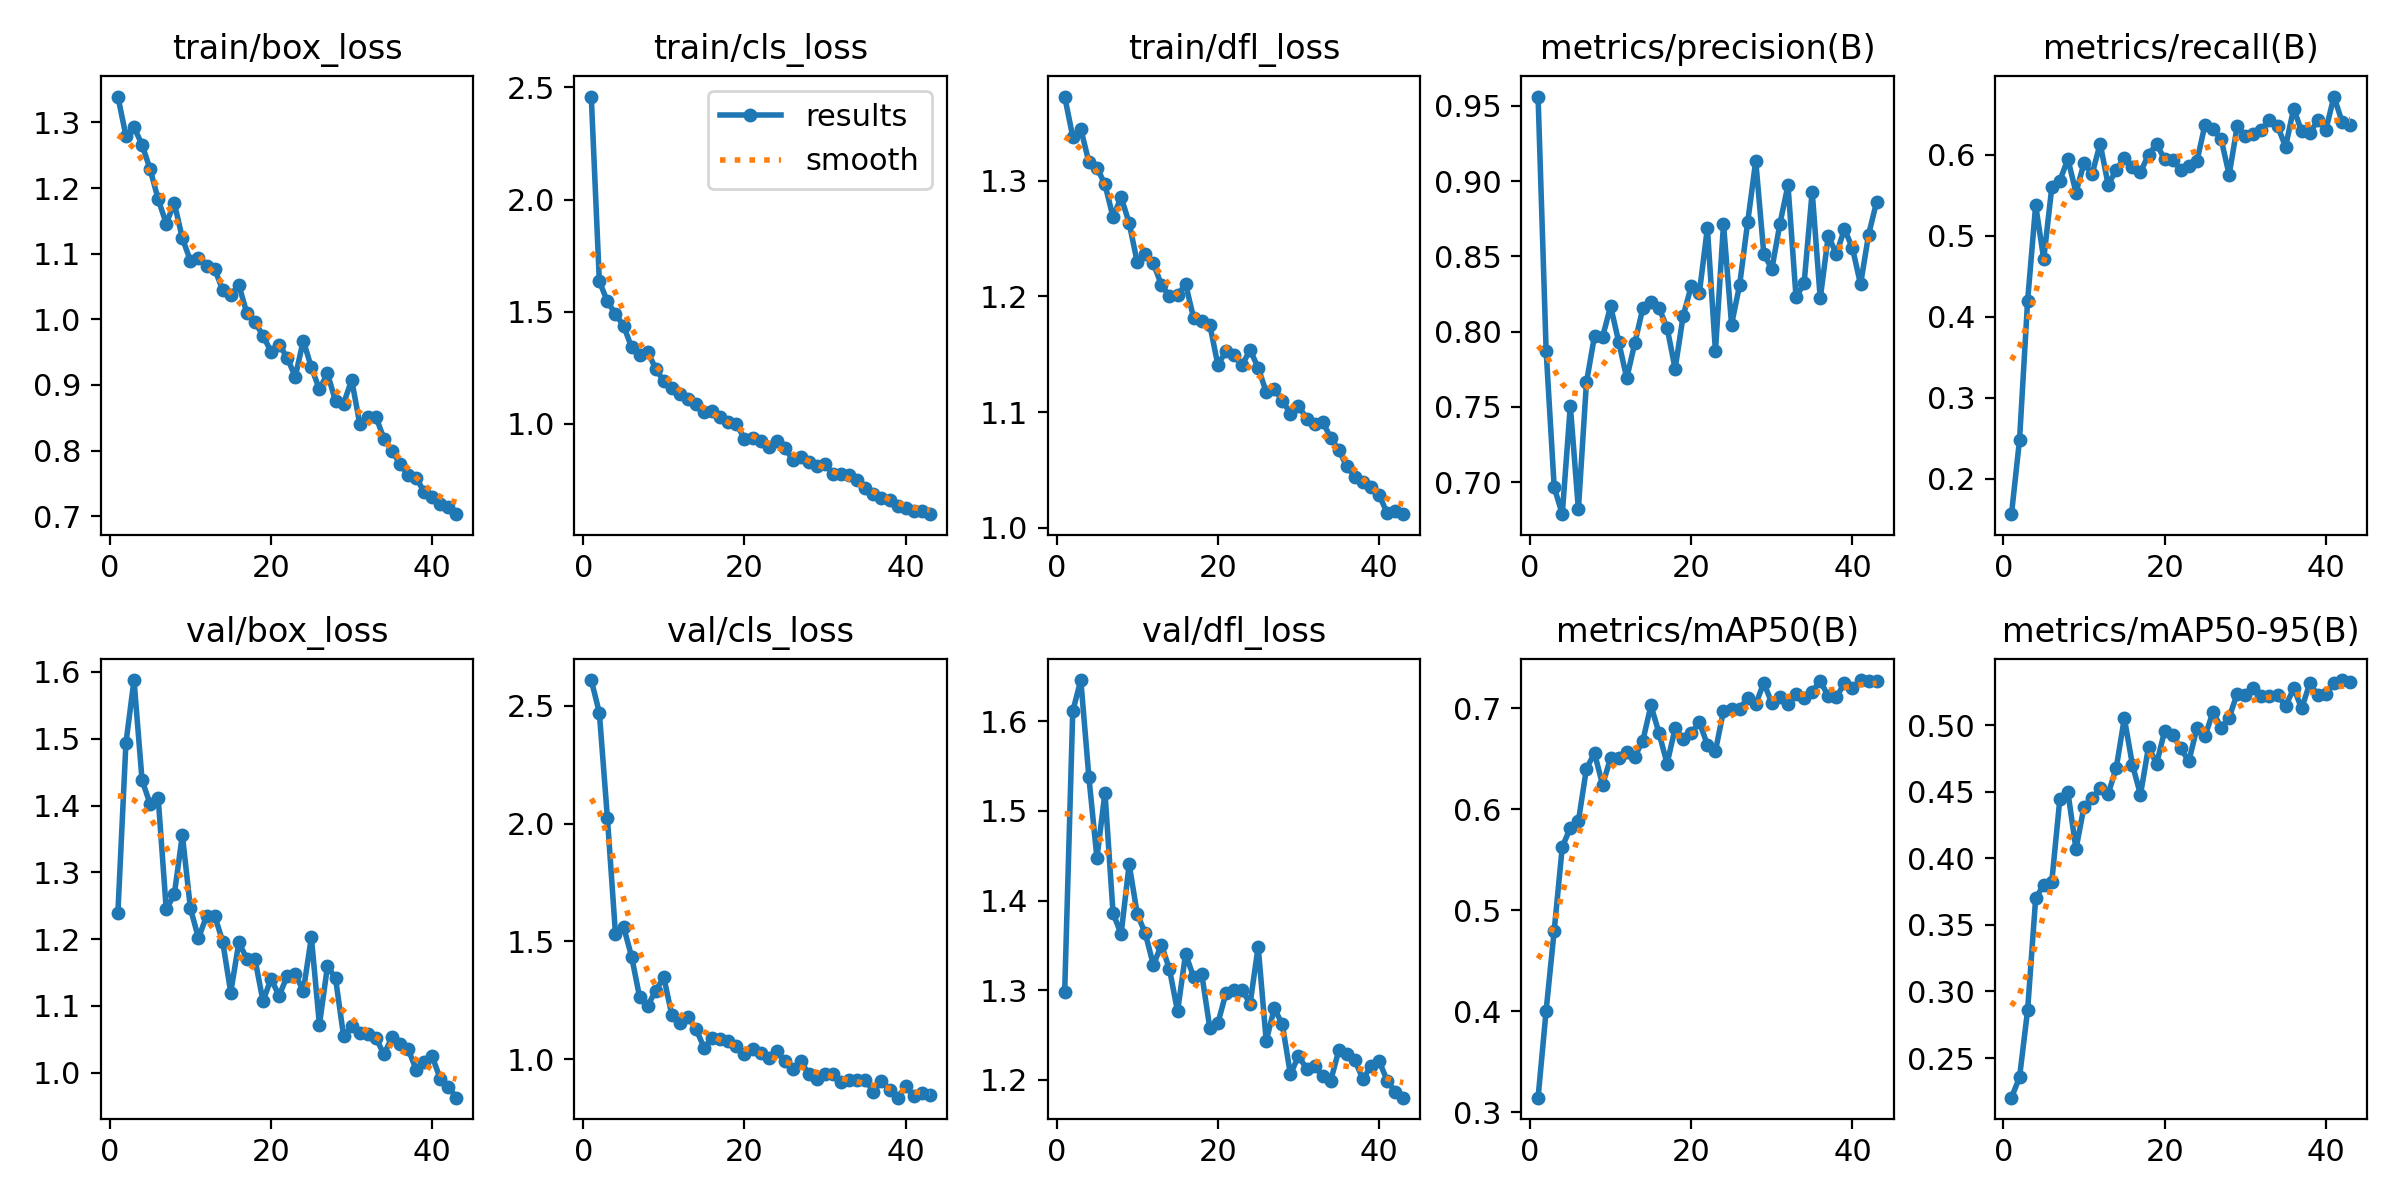

Loading from local: /content/runs/detect/train/confusion_matrix.png


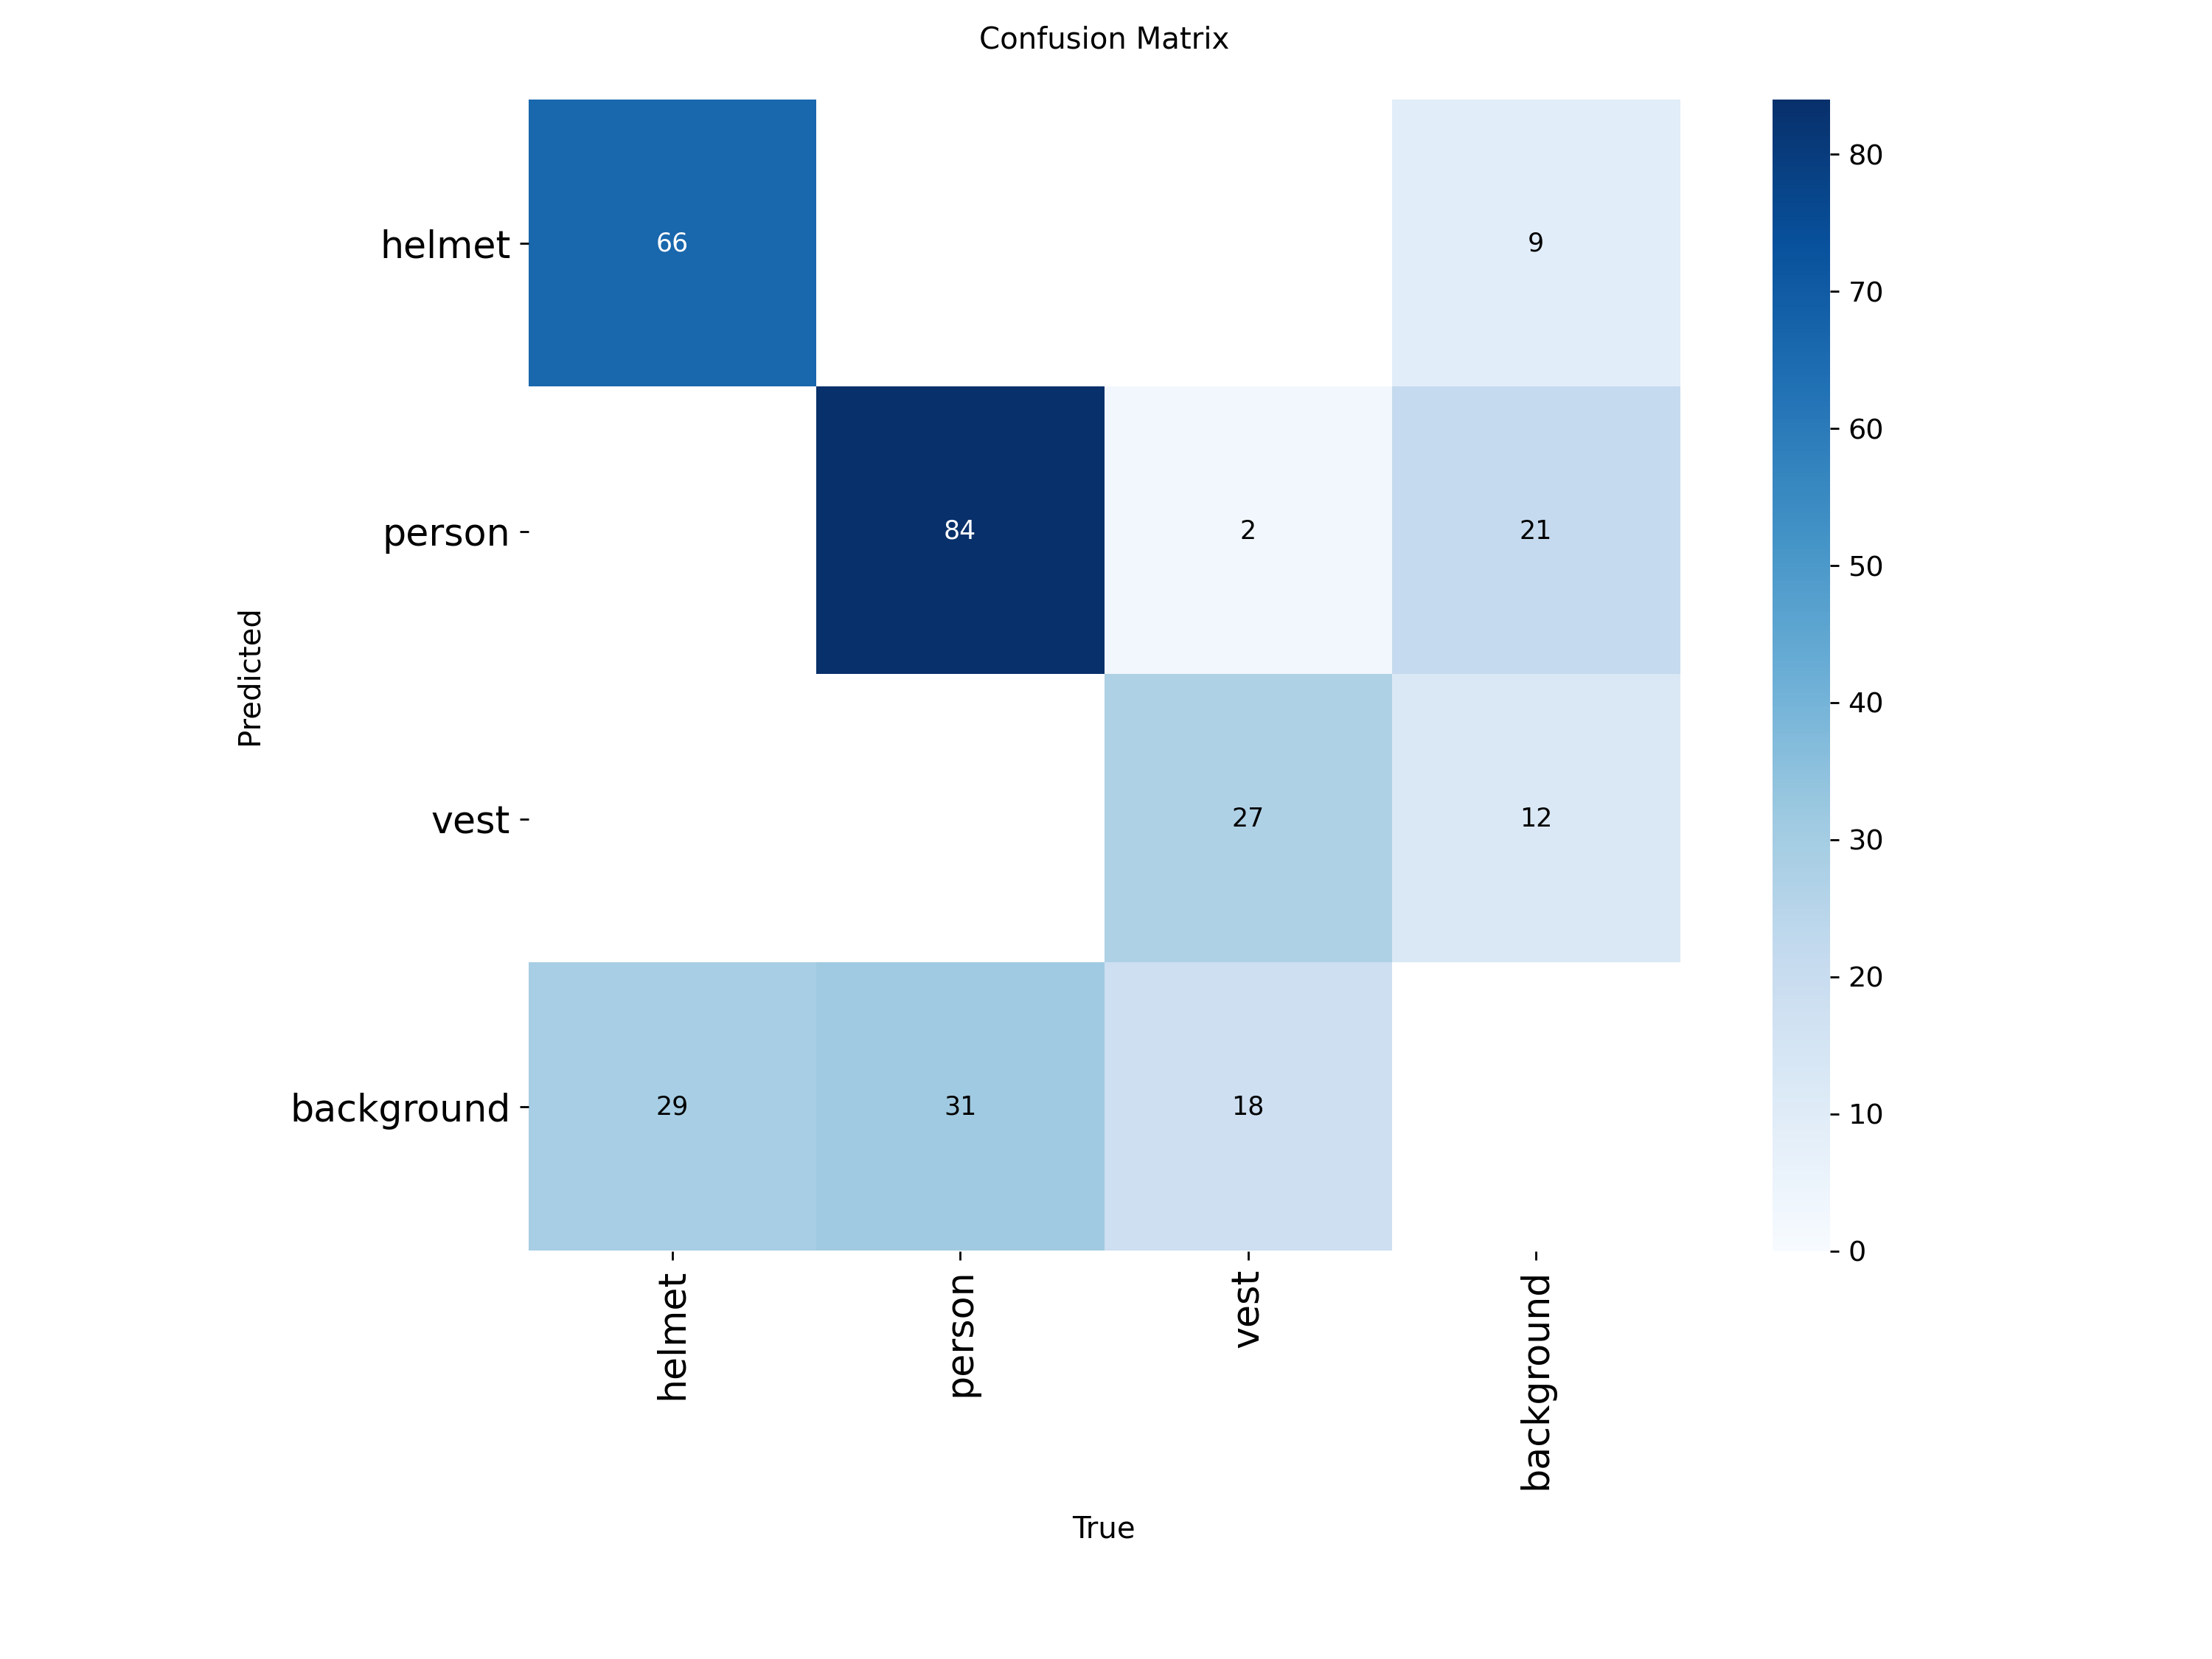

--2026-04-02 12:25:40--  https://drive.google.com/uc?id=1dgwYS2gO9RLQIxBCLlrL5UA7WgN_mJOl
Resolving drive.google.com (drive.google.com)... 142.251.12.113, 142.251.12.100, 142.251.12.139, ...
Connecting to drive.google.com (drive.google.com)|142.251.12.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1dgwYS2gO9RLQIxBCLlrL5UA7WgN_mJOl [following]
--2026-04-02 12:25:40--  https://drive.usercontent.google.com/download?id=1dgwYS2gO9RLQIxBCLlrL5UA7WgN_mJOl
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.4.132, 2404:6800:4003:c11::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.4.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 147660 (144K) [image/png]
Saving to: ‘recall_curve.png’

recall_curve.png    100%[===================>] 144.20K  --.-KB/s    in 0.001s  

2026-04-02 12:25:41 (98.7 MB/s) - ‘recall_curve

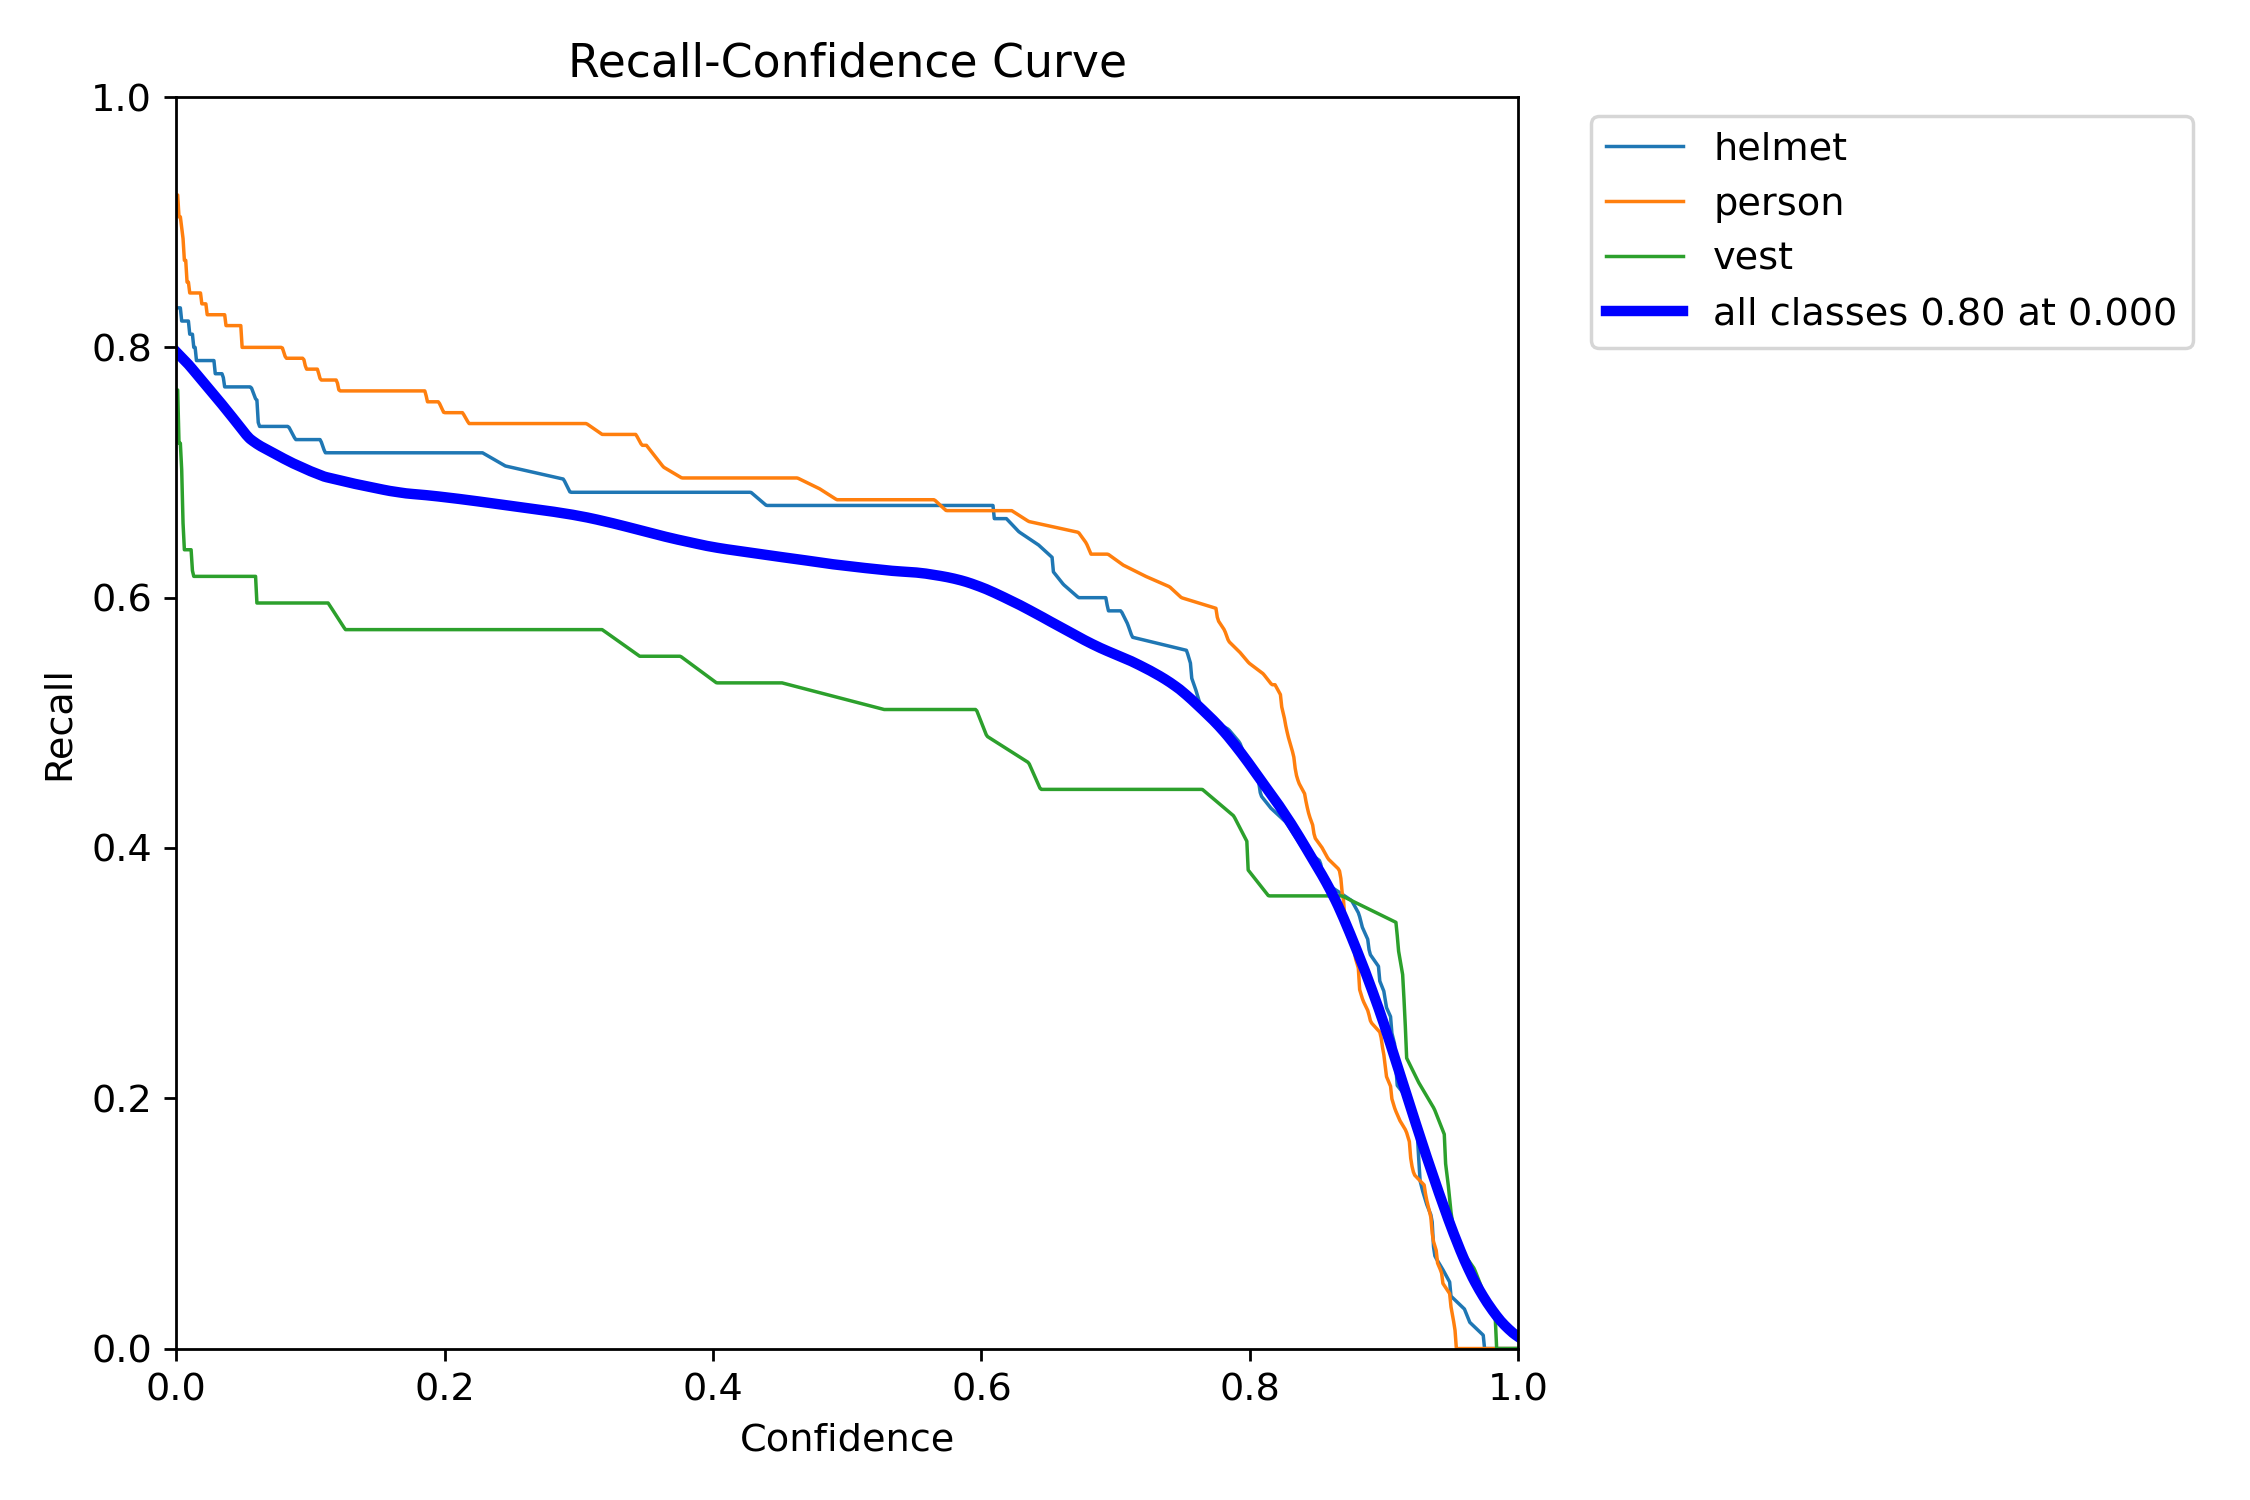

In [4]:
import os
from IPython.display import Image, display

# Function to load image with fallback
def load_image(local_path, drive_link, save_name):
    if os.path.exists(local_path):
        print(f"Loading from local: {local_path}")
        display(Image(filename=local_path))
    else:
        print(f"Downloading from Drive: {save_name}")
        !wget "{drive_link}" -O {save_name}
        display(Image(filename=save_name))


# 1️⃣ Training Results Graph
load_image(
    local_path="/content/runs/detect/train/results.png",
    drive_link="https://drive.google.com/uc?id=1X3xKoBMONwFYh-uXQ6tgdZ0tFrXBJ-PE",
    save_name="results.png"
)

# 2️⃣ Confusion Matrix
load_image(
    local_path="/content/runs/detect/train/confusion_matrix.png",
    drive_link="https://drive.google.com/uc?id=1FvR8RbgvTQi5bpoHsjgPt4Os6J3k_QIz",
    save_name="confusion_matrix.png"
)

# 3️⃣ Recall-Confidence Curve
load_image(
    local_path="/content/runs/detect/train/R_curve.png",
    drive_link="https://drive.google.com/uc?id=1dgwYS2gO9RLQIxBCLlrL5UA7WgN_mJOl",
    save_name="recall_curve.png"
)

#Metrics

In [5]:
metrics = model.val()

print("Precision:", metrics.results_dict['metrics/precision(B)'])
print("Recall:", metrics.results_dict['metrics/recall(B)'])
print("mAP50:", metrics.results_dict['metrics/mAP50(B)'])
print("mAP50-95:", metrics.results_dict['metrics/mAP50-95(B)'])

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1569.0±685.2 MB/s, size: 51.2 KB)
val: Scanning /content/PPE-Detection-10/valid/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 11.8Mit/s 0.0s
val: /content/PPE-Detection-10/valid/images/14_png.rf.b912bd0182e85f771c846fc668796aca.jpg: 1 duplicate labels removed
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 245, len(boxes) = 257. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.7it/s 1.2s
                   all         31        257      0.846      0.658      0.727      0.533
          

# Helper Function

In [6]:
def box_area(box):
    x1, y1, x2, y2 = box
    return max(0, x2 - x1) * max(0, y2 - y1)

def intersection_area(boxA, boxB):
    ax1, ay1, ax2, ay2 = boxA
    bx1, by1, bx2, by2 = boxB

    x1 = max(ax1, bx1)
    y1 = max(ay1, by1)
    x2 = min(ax2, bx2)
    y2 = min(ay2, by2)

    if x2 <= x1 or y2 <= y1:
        return 0
    return (x2 - x1) * (y2 - y1)

def overlap_ratio(inner, outer):
    inter = intersection_area(inner, outer)
    inner_area = box_area(inner)
    if inner_area == 0:
        return 0
    return inter / inner_area

def is_valid_person(box, min_area=12000):
    x1, y1, x2, y2 = box
    width = x2 - x1
    height = y2 - y1
    area = width * height

    # reject tiny or very thin weird boxes
    if area < min_area:
        return False
    if width < 40 or height < 80:
        return False

    return True

def helmet_belongs_to_person(helmet_box, person_box):
    hx1, hy1, hx2, hy2 = helmet_box
    px1, py1, px2, py2 = person_box

    cx = (hx1 + hx2) / 2
    cy = (hy1 + hy2) / 2

    upper_limit = py1 + 0.35 * (py2 - py1)
    return px1 <= cx <= px2 and py1 <= cy <= upper_limit

def vest_belongs_to_person(vest_box, person_box, threshold=0.3):
    px1, py1, px2, py2 = person_box

    torso_box = [
        px1,
        py1 + 0.2 * (py2 - py1),
        px2,
        py1 + 0.75 * (py2 - py1)
    ]

    return overlap_ratio(vest_box, torso_box) >= threshold

#Testing

In [8]:
from ultralytics import YOLO
results = model.predict(
    source="/content/PPE-Detection-10/test/images",
    save=True,
    conf=0.25
)


image 1/23 /content/PPE-Detection-10/test/images/12_png.rf.05740d2566a6f01553dfccb58ff03642.jpg: 640x640 2 helmets, 2 persons, 2 vests, 7.2ms
image 2/23 /content/PPE-Detection-10/test/images/18_png.rf.53a766dea7b434f63271654a26fc0695.jpg: 640x640 2 helmets, 2 persons, 7.2ms
image 3/23 /content/PPE-Detection-10/test/images/200_png.rf.c5f2e4b57e9383ed6c81fbc3102f1526.jpg: 640x640 1 person, 2 vests, 7.2ms
image 4/23 /content/PPE-Detection-10/test/images/214_png.rf.568e2b18b3734f62e4c3df2c158430b6.jpg: 640x640 1 helmet, 1 person, 1 vest, 7.2ms
image 5/23 /content/PPE-Detection-10/test/images/215_png.rf.fb583c01436532f5183e36eb255e4136.jpg: 640x640 1 helmet, 2 persons, 7.2ms
image 6/23 /content/PPE-Detection-10/test/images/218_png.rf.722ccd9a9d5ca96632e023c0cea5a8e4.jpg: 640x640 1 helmet, 1 person, 7.2ms
image 7/23 /content/PPE-Detection-10/test/images/39_png.rf.ebd2d16af52e42bcc335f4b4baec6be6.jpg: 640x640 3 persons, 7.2ms
image 8/23 /content/PPE-Detection-10/test/images/43_png.rf.06732fe

#Core Safety Logic

In [9]:
def avg_conf(scores):
    return sum(scores) / len(scores) if scores else 0.0


def analyze_image(image_path):
    results = model.predict(source=image_path, conf=0.15, save=False)
    boxes = results[0].boxes
    names = model.names

    persons = []
    helmets = []
    vests = []

    # collect detections with confidence
    for box, cls, conf in zip(boxes.xyxy, boxes.cls, boxes.conf):
        label = names[int(cls)]
        coords = box.tolist()
        conf = float(conf)

        if label == "person":
            if conf >= 0.40 and is_valid_person(coords, min_area=12000):
                persons.append({"box": coords, "conf": conf})

        elif label == "helmet":
            if conf >= 0.20:
                helmets.append({"box": coords, "conf": conf})

        elif label == "vest":
            if conf >= 0.10:
                vests.append({"box": coords, "conf": conf})

    worker_results = []
    scene_safe = True

    used_helmets = set()
    used_vests = set()

    for person_idx, person_item in enumerate(persons):
        person = person_item["box"]
        person_conf = person_item["conf"]

        # find best helmet for this person
        matched_helmet = None
        best_helmet_conf = -1

        for i, h in enumerate(helmets):
            if i in used_helmets:
                continue
            if helmet_belongs_to_person(h["box"], person):
                if h["conf"] > best_helmet_conf:
                    best_helmet_conf = h["conf"]
                    matched_helmet = i

        # find best vest for this person
        matched_vest = None
        best_vest_conf = -1
        best_vest_score = -1

        torso_box = [
            person[0],
            person[1] + 0.2 * (person[3] - person[1]),
            person[2],
            person[1] + 0.8 * (person[3] - person[1]),
        ]

        for i, v in enumerate(vests):
            if i in used_vests:
                continue

            score = overlap_ratio(v["box"], torso_box)

            if score >= 0.15 and score > best_vest_score:
                best_vest_score = score
                best_vest_conf = v["conf"]
                matched_vest = i


        has_helmet = matched_helmet is not None
        has_vest = matched_vest is not None

        helmet_conf = best_helmet_conf if has_helmet else None
        vest_conf = best_vest_conf if has_vest else None

        helmet_box = helmets[matched_helmet]["box"] if has_helmet else None
        vest_box = vests[matched_vest]["box"] if has_vest else None

        if matched_helmet is not None:
            used_helmets.add(matched_helmet)

        if matched_vest is not None:
            used_vests.add(matched_vest)

        violations = []
        if not has_helmet:
            violations.append("missing helmet")
        if not has_vest:
            violations.append("missing vest")

        safe = has_helmet and has_vest
        if not safe:
            scene_safe = False

        conf_parts = [person_conf]
        if has_helmet:
            conf_parts.append(best_helmet_conf)
        if has_vest:
            conf_parts.append(best_vest_conf)

        worker_confidence = round(avg_conf(conf_parts), 3)
        review_needed = worker_confidence < 0.45

        worker_results.append({
            "person_box": person,
            "person_conf": person_conf,
            "helmet": has_helmet,
            "helmet_conf": helmet_conf,
            "helmet_box": helmet_box,
            "vest": has_vest,
            "vest_conf": vest_conf,
            "vest_box": vest_box,
            "status": "safe" if safe else "unsafe",
            "violations": violations,
            "confidence": worker_confidence,
            "review_needed": review_needed
        })


    scene_confidence = round(
        avg_conf([w["confidence"] for w in worker_results]), 3
    ) if worker_results else 0.0

    return {
        "scene_status": "safe" if scene_safe else "unsafe",
        "scene_confidence": scene_confidence,
        "workers": worker_results
    }

#Alert Generation

In [10]:
def generate_alert_report(result):
    lines = []

    scene_status = result.get("scene_status", "unknown").upper()
    scene_conf = result.get("scene_confidence", 0.0)
    workers = result.get("workers", [])

    total_workers = len(workers)
    safe_workers = sum(1 for w in workers if w.get("status", "").lower() == "safe")
    unsafe_workers = total_workers - safe_workers

    # Header
    scene_icon = "✅" if scene_status == "SAFE" else "🚨"
    lines.append("=" * 55)
    lines.append(f"{scene_icon} PPE SAFETY ALERT REPORT")
    lines.append("=" * 55)
    lines.append(f"Scene Status      : {scene_status}")
    lines.append(f"Scene Confidence  : {scene_conf:.2f}")
    lines.append(f"Total Workers     : {total_workers}")
    lines.append(f"Safe Workers      : {safe_workers}")
    lines.append(f"Unsafe Workers    : {unsafe_workers}")
    lines.append("-" * 55)

    # Worker details
    for i, w in enumerate(workers, start=1):
        worker_status = w.get("status", "unknown").upper()
        worker_conf = w.get("confidence", 0.0)
        person_conf = w.get("person_conf", 0.0)

        helmet_detected = w.get("helmet", False)
        helmet_conf = w.get("helmet_conf", 0.0)

        vest_detected = w.get("vest", False)
        vest_conf = w.get("vest_conf", 0.0)

        violations = w.get("violations", [])
        review_needed = w.get("review_needed", False)

        status_icon = "✅" if worker_status == "SAFE" else "❌"

        lines.append(f"👷 Worker {i}")
        lines.append(f"   Status             : {status_icon} {worker_status}")
        lines.append(f"   Person Confidence  : {person_conf:.2f}")

        if helmet_detected:
            lines.append(f"   Helmet             : YES 🪖 ({helmet_conf:.2f})")
        else:
            lines.append("   Helmet             : NO 🪖")

        if vest_detected:
            lines.append(f"   Vest               : YES 🦺 ({vest_conf:.2f})")
        else:
            lines.append("   Vest               : NO 🦺")

        if violations:
            lines.append(f"   Violations         : {', '.join(violations)}")
        else:
            lines.append("   Violations         : None")

        lines.append(f"   Worker Confidence  : {worker_conf:.2f}")

        if review_needed:
            lines.append("   Review             : ⚠️ Manual review recommended")

        lines.append("-" * 55)

    # Final summary
    if unsafe_workers == 0:
        lines.append("🎉 All detected workers comply with PPE rules.")
    else:
        lines.append(f"⚠️ Action needed: {unsafe_workers} worker(s) have PPE violations.")

    lines.append("=" * 55)

    return "\n".join(lines)

Saving 13.png to 13.png
Uploaded image: 13.png


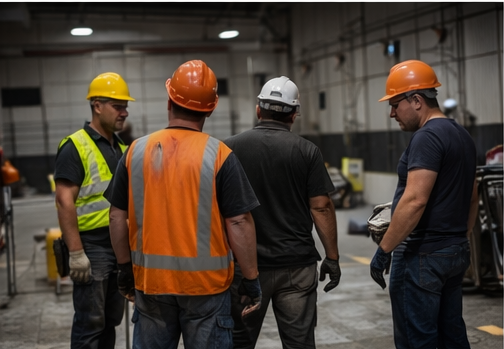


image 1/1 /content/13.png: 448x640 4 helmets, 5 persons, 2 vests, 54.7ms
Speed: 6.6ms preprocess, 54.7ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
🚨 PPE SAFETY ALERT REPORT
Scene Status      : UNSAFE
Scene Confidence  : 0.91
Total Workers     : 4
Safe Workers      : 2
Unsafe Workers    : 2
-------------------------------------------------------
👷 Worker 1
   Status             : ✅ SAFE
   Person Confidence  : 0.94
   Helmet             : YES 🪖 (0.87)
   Vest               : YES 🦺 (0.92)
   Violations         : None
   Worker Confidence  : 0.91
-------------------------------------------------------
👷 Worker 2
   Status             : ✅ SAFE
   Person Confidence  : 0.93
   Helmet             : YES 🪖 (0.85)
   Vest               : YES 🦺 (0.92)
   Violations         : None
   Worker Confidence  : 0.90
-------------------------------------------------------
👷 Worker 3
   Status             : ❌ UNSAFE
   Person Confidence  : 0.92
   Helmet             : YES 🪖 (0.92)
 

In [19]:
from google.colab import files
from IPython.display import display, Image

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

print("Uploaded image:", image_path)
display(Image(filename=image_path))

result = analyze_image(image_path)
print(generate_alert_report(result))

In [20]:
from PIL import Image as PILImage, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def visualize_safety_result(image_path, result):
    img = PILImage.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", 18)
    except:
        font = ImageFont.load_default()

    for i, worker in enumerate(result["workers"], start=1):
        # Person
        px1, py1, px2, py2 = map(int, worker["person_box"])
        status = worker["status"]
        violations = worker.get("violations", [])
        person_conf = worker.get("person_conf", 0.0)

        person_color = "green" if status == "safe" else "red"

        # Draw person box
        draw.rectangle([px1, py1, px2, py2], outline=person_color, width=4)

        if status == "safe":
            person_label = f"W{i}: SAFE ({person_conf:.2f})"
        else:
            reason = ", ".join(violations) if violations else "PPE missing"
            person_label = f"W{i}: UNSAFE ({person_conf:.2f})"

        p_text_y = max(0, py1 - 28)
        p_bbox = draw.textbbox((px1, p_text_y), person_label, font=font)
        draw.rectangle(p_bbox, fill=person_color)
        draw.text((px1, p_text_y), person_label, fill="white", font=font)

        # Helmet box
        if worker.get("helmet") and worker.get("helmet_box") is not None:
            hx1, hy1, hx2, hy2 = map(int, worker["helmet_box"])
            helmet_conf = worker.get("helmet_conf", 0.0)

            draw.rectangle([hx1, hy1, hx2, hy2], outline="blue", width=3)

            helmet_label = f"helmet {helmet_conf:.2f}"
            h_text_y = max(0, hy1 - 22)
            h_bbox = draw.textbbox((hx1, h_text_y), helmet_label, font=font)
            draw.rectangle(h_bbox, fill="blue")
            draw.text((hx1, h_text_y), helmet_label, fill="white", font=font)

        # Vest box
        if worker.get("vest") and worker.get("vest_box") is not None:
            vx1, vy1, vx2, vy2 = map(int, worker["vest_box"])
            vest_conf = worker.get("vest_conf", 0.0)

            draw.rectangle([vx1, vy1, vx2, vy2], outline="orange", width=3)

            vest_label = f"vest {vest_conf:.2f}"
            v_text_y = max(0, vy1 - 22)
            v_bbox = draw.textbbox((vx1, v_text_y), vest_label, font=font)
            draw.rectangle(v_bbox, fill="orange")
            draw.text((vx1, v_text_y), vest_label, fill="white", font=font)

    # Scene label
    scene_status = result.get("scene_status", "unknown")
    scene_conf = result.get("scene_confidence", 0.0)
    scene_color = "green" if scene_status == "safe" else "red"
    scene_label = f"Scene: {scene_status.upper()} ({scene_conf:.2f})"

    s_bbox = draw.textbbox((10, 10), scene_label, font=font)
    draw.rectangle(s_bbox, fill=scene_color)
    draw.text((10, 10), scene_label, fill="white", font=font)

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    return img

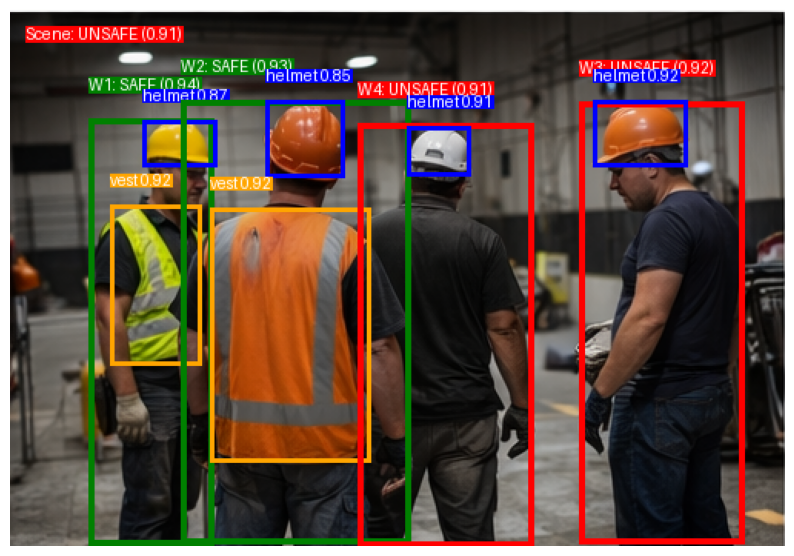

In [21]:
visualized_img = visualize_safety_result(image_path, result)